# STEP 1. 데이터 다운로드 및 탐색적 데이터 분석

In [1]:
import os
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import numpy as np
import cv2
from collections import Counter
from pathlib import Path

### 경로 설정

In [24]:
import os
from pathlib import Path
from collections import Counter

# 1. 최상위 폴더를 지정 (반드시 'r'을 붙이고, 압축 푼 폴더까지만!)
DATA_ROOT = Path(r"C:\workspace_python\deeplearning\project\pcb-defects")

def collect_stats(root_path):
    # .rglob("*.xml")은 하위 폴더가 몇 개든 상관없이 모든 .xml을 다 찾습니다.
    xml_files = list(root_path.rglob("*.xml"))
    
    print(f"[INFO] 탐색 경로: {root_path}")
    print(f"[INFO] 총 XML 파일 수: {len(xml_files)}")

    if len(xml_files) == 0:
        print("❌ 파일을 찾지 못했습니다! 폴더명을 다시 확인해주세요.")
        # 실제 어떤 폴더들이 있는지 출력해서 확인
        print(f"현재 경로에 있는 것들: {os.listdir(root_path) if root_path.exists() else '경로 없음'}")
        return [], Counter(), []

    # ... 이후 로직 동일 ...
    return xml_files, Counter(), [] # (생략)

# 실행
xml_files, class_counter, bbox_areas = collect_stats(DATA_ROOT)

[INFO] 탐색 경로: C:\workspace_python\deeplearning\project\pcb-defects
[INFO] 총 XML 파일 수: 693


### XML 파싱 함수 (Pascal VOC 형식)

In [25]:
def parse_voc_xml(xml_path):
    """
    Pascal VOC XML → dict 리스트 반환
    반환: [{"class": str, "xmin": int, "ymin": int, "xmax": int, "ymax": int}, ...]
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    img_w = int(root.find("size/width").text)
    img_h = int(root.find("size/height").text)
    filename = root.find("filename").text

    objects = []
    for obj in root.findall("object"):
        cls  = obj.find("name").text.strip().lower().replace(" ", "_")
        xmin = int(obj.find("bndbox/xmin").text)
        ymin = int(obj.find("bndbox/ymin").text)
        xmax = int(obj.find("bndbox/xmax").text)
        ymax = int(obj.find("bndbox/ymax").text)
        objects.append({
            "class": cls, "xmin": xmin, "ymin": ymin,
            "xmax": xmax, "ymax": ymax,
            "img_w": img_w, "img_h": img_h
        })
    return filename, objects

print('[OK] 함수 정의 완료')

[OK] 함수 정의 완료


### 전체 XML 수집 및 통계 계산

In [40]:
# def collect_stats(annot_dir):
#     xml_files = list(Path(annot_dir).rglob("*.xml"))
#     print(f"[INFO] 총 XML 파일 수: {len(xml_files)}")

#     all_objects   = []
#     class_counter = Counter()
#     bbox_areas    = []

#     for xf in xml_files:
#         try:
#             fname, objs = parse_voc_xml(xf)
#             for o in objs:
#                 all_objects.append(o)
#                 class_counter[o["class"]] += 1
#                 area = (o["xmax"] - o["xmin"]) * (o["ymax"] - o["ymin"])
#                 bbox_areas.append(area)
#         except Exception as e:
#             print(f"[WARN] 파싱 오류: {xf} → {e}")

#     print(f"[INFO] 총 객체(결함) 수: {len(all_objects)}")
#     print(f"[INFO] 클래스별 분포:")
#     for cls, cnt in sorted(class_counter.items(), key=lambda x: -x[1]):
#         print(f"       {cls:<20}: {cnt}")
#     return xml_files, class_counter, bbox_areas

# xml_files, class_counter, bbox_areas = collect_stats(DATA_ROOT)

In [41]:
def collect_stats(annot_dir):
    xml_files = list(Path(annot_dir).rglob("*.xml"))
    print(f"[INFO] 총 XML 파일 수: {len(xml_files)}")

    all_objects   = []
    class_counter = Counter()
    bbox_areas    = []

    for xf in xml_files:
        try:
            fname, objs = parse_voc_xml(xf)
            for o in objs:
                all_objects.append(o)
                class_counter[o["class"]] += 1
                area = (o["xmax"] - o["xmin"]) * (o["ymax"] - o["ymin"])
                bbox_areas.append(area)
        except Exception as e:
            print(f"[WARN] 파싱 오류: {xf} → {e}")

    print(f"[INFO] 총 객체(결함) 수: {len(all_objects)}")
    return xml_files, class_counter, bbox_areas

### EDA 시각화

In [42]:
# def visualize_sample(root_dir, n=4):
#     # root_dir 아래의 모든 xml 파일을 찾고 그중 n개를 샘플링합니다.
#     xml_files = list(Path(root_dir).rglob("*.xml"))
#     import random
#     if len(xml_files) > n:
#         xml_files = random.sample(xml_files, n)
    
#     # 서브플롯 설정
#     fig, axes = plt.subplots(1, len(xml_files), figsize=(5*len(xml_files), 5))
#     if len(xml_files) == 1: axes = [axes]

#     for ax, xf in zip(axes, xml_files):
#         fname, objs = parse_voc_xml(xf) # 여기서 fname은 보통 파일명만 들어있음

#         # 핵심: XML 파일과 같은 폴더 혹은 그 근처 하위 폴더에서 이미지를 찾습니다.
#         img_path = None
#         # XML 파일이 위치한 폴더의 부모 폴더(root)에서 해당 파일명을 가진 이미지를 검색
#         for ext in [".jpg", ".JPG", ".png", ".PNG"]:
#             # xf.parent.parent 등을 통해 images 폴더를 유추하거나 rglob으로 찾기
#             candidate = list(Path(root_dir).rglob(Path(fname).stem + ext))
#             if candidate:
#                 img_path = candidate[0]
#                 break

#         if img_path is None:
#             ax.set_title(f"Image Not Found\n{fname}", fontsize=8)
#             ax.axis("off")
#             continue

#         # 이미지 로드 및 시각화 (기존 로직 동일)
#         img = cv2.imread(str(img_path))
#         if img is not None:
#             img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#             ax.imshow(img)

In [47]:
def visualize_sample(root_dir, n=4):
    xml_files = list(Path(root_dir).rglob("*.xml"))
    import random
    if len(xml_files) > n:
        xml_files = random.sample(xml_files, n)
    
    fig, axes = plt.subplots(1, len(xml_files), figsize=(5*len(xml_files), 5))
    if len(xml_files) == 1: axes = [axes]

    COLOR_MAP = {
        "missing_hole": "#E63946", "mouse_bite": "#457B9D",
        "open_circuit": "#2A9D8F", "short": "#E9C46A",
        "spur": "#F4A261", "spurious_copper": "#264653",
    }

    for ax, xf in zip(axes, xml_files):
        fname, objs = parse_voc_xml(xf)
        
        # 이미지 찾기
        img_path = None
        for ext in [".jpg", ".JPG", ".png", ".PNG"]:
            candidate = list(Path(root_dir).rglob(Path(fname).stem + ext))
            if candidate:
                img_path = candidate[0]
                break

        if img_path is None:
            continue

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)

        # visualize_sample 함수 내의 박스 그리는 부분(o in objs 루프 안)을 수정하세요
        for o in objs:
            cls = o["class"]
            color = COLOR_MAP.get(cls, "lime") # 기본색을 형광 초록(lime)으로 설정
            
            # 1. 선 두께를 15로 대폭 상향
            # 2. facecolor와 alpha를 추가하여 박스 영역을 색칠함
            rect = patches.Rectangle(
                (o["xmin"], o["ymin"]),
                o["xmax"] - o["xmin"], o["ymax"] - o["ymin"],
                linewidth=15,             # 2 -> 15로 수정
                edgecolor=color, 
                facecolor=color,         # 박스 안쪽 색상 채우기
                alpha=0.3,               # 투명도 30% (기판이 보이게)
                fill=True
            )
            ax.add_patch(rect)
            
            # 3. 라벨 텍스트도 더 크게 수정
            ax.text(o["xmin"], o["ymin"] - 40, cls, 
                    color="white", fontsize=15, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.3", fc=color, ec="none", alpha=0.9))
            
            rect = patches.Rectangle(
                (o["xmin"], o["ymin"]),
                o["xmax"] - o["xmin"], o["ymax"] - o["ymin"],
                linewidth=12,            # 2 -> 12로 대폭 상향 (고해상도 대응)
                edgecolor="#FF0000",     # 가장 눈에 잘 띄는 순수 빨강
                facecolor="#FF0000",     # 박스 내부도 색을 채움
                alpha=0.3,               # 투명도를 주어 기판이 보이게 함
                fill=True
            )
            ax.add_patch(rect)
            ax.text(o["xmin"], o["ymin"] - 20, cls, color="white", 
                    fontsize=12, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.3", fc=color, alpha=0.9))
        ax.axis("off")
    plt.show()

### 실행

[INFO] 총 XML 파일 수: 693
[INFO] 총 객체(결함) 수: 2953


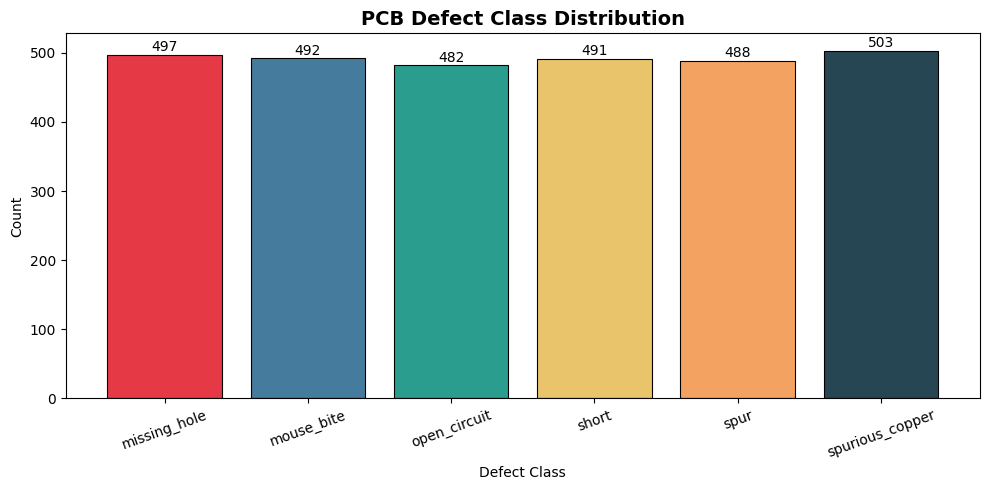

[SAVE] eda_class_distribution.png


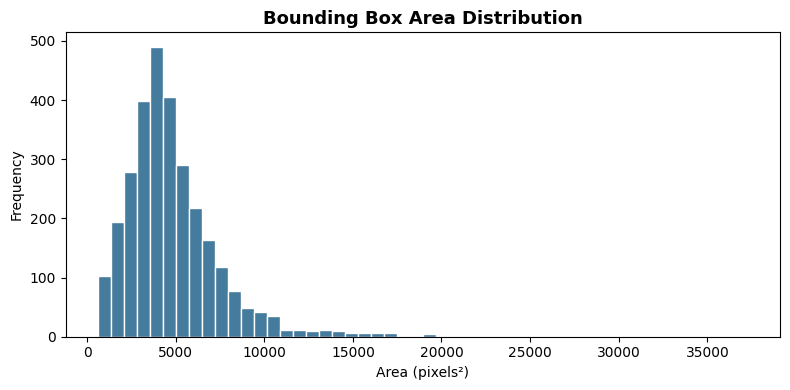

[SAVE] eda_bbox_area.png


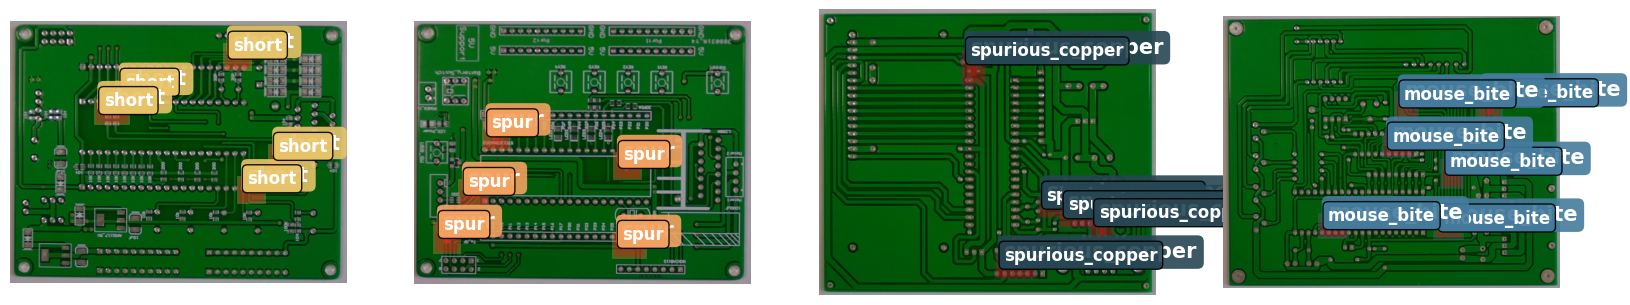

In [49]:
if __name__ == "__main__":
    DATA_ROOT = Path(r"C:\workspace_python\deeplearning\project\pcb-defects")
    
    # 1. 통계 수집
    xml_files, class_counter, bbox_areas = collect_stats(DATA_ROOT)
    
    # 2. 통계 시각화
    if class_counter:
        plot_class_distribution(class_counter)
        plot_bbox_area_histogram(bbox_areas)
    
    # 3. 샘플 이미지 시각화 (수정된 함수 호출)
    visualize_sample(DATA_ROOT, n=4)